# Exploratory Data Analysis (EDA)



Will the removal of level crossings and related transport improvements along the Upfield line drive faster house price growth in adjacent suburbs compared to those located away from the line?

Focusing on three main variables:
- Suburb
- House price
- Population density

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

project_root = Path.cwd()
if not (project_root / "data" / "clean").exists():
    project_root = project_root.parent
clean_dir = project_root / "data" / "clean"

# 1) House prices (56-suburb table)
prices_path = clean_dir / "closest_lxrp_site_house_prices_2015_2024.csv"
prices_wide = pd.read_csv(prices_path)

# Fix common typo if present.
prices_wide["Suburb"] = prices_wide["Suburb"].replace({"Tullarmarine": "Tullamarine"})

price_years = [c for c in prices_wide.columns if c != "Suburb"]
prices_long = prices_wide.melt(
    id_vars="Suburb",
    value_vars=price_years,
    var_name="Year",
    value_name="HousePrice",
)
prices_long["Year"] = pd.to_numeric(prices_long["Year"], errors="coerce").astype("Int64")
prices_long["HousePrice"] = pd.to_numeric(prices_long["HousePrice"], errors="coerce")
prices_long = prices_long.dropna(subset=["Year", "HousePrice"]).copy()
prices_long["Year"] = prices_long["Year"].astype(int)

# 2) Population density (supports wide or long outputs and year ranges)
density_candidates = [
    clean_dir / "requested_suburbs_density_2015_2024.csv",
    clean_dir / "requested_suburbs_density_2018_2025.csv",
    clean_dir / "requested_suburbs_density_2015_2024_long.csv",
    clean_dir / "requested_suburbs_density_2018_2025_long.csv",
]

density_path = next((p for p in density_candidates if p.exists()), None)
if density_path is None:
    raise FileNotFoundError(
        "No requested_suburbs_density file found in data/clean. "
        "Expected one of: requested_suburbs_density_2015_2024(.csv/_long.csv) "
        "or requested_suburbs_density_2018_2025(.csv/_long.csv)."
    )

density_raw = pd.read_csv(density_path)

if {"Suburb", "Year", "Density"}.issubset(density_raw.columns):
    density_long = density_raw[["Suburb", "Year", "Density"]].copy()
else:
    wide_cols = [c for c in density_raw.columns if str(c).isdigit()]
    id_cols = [c for c in ["Suburb"] if c in density_raw.columns]
    if not id_cols or not wide_cols:
        raise ValueError("Density file format is not recognized.")
    density_long = density_raw[id_cols + wide_cols].melt(
        id_vars=id_cols,
        value_vars=wide_cols,
        var_name="Year",
        value_name="Density",
    )

density_long["Year"] = pd.to_numeric(density_long["Year"], errors="coerce").astype("Int64")
density_long["Density"] = pd.to_numeric(density_long["Density"], errors="coerce")
density_long = density_long.dropna(subset=["Suburb", "Year", "Density"]).copy()
density_long["Year"] = density_long["Year"].astype(int)

# Keep only overlapping years between price and density tables.
common_years = sorted(set(prices_long["Year"]).intersection(set(density_long["Year"])))
prices_long = prices_long[prices_long["Year"].isin(common_years)].copy()
density_long = density_long[density_long["Year"].isin(common_years)].copy()

# 3) Distance-to-nearest-LXRP-site proxy for adjacency (0-3 km = adjacent)
suburb_distance_pairs = [
    ("Chelsea", 4), ("Laverton", 3), ("Ringwood", 2), ("Mentone", 2), ("Preston", 1),
    ("Blackburn", 2), ("Beaconsfield", 2), ("Essendon", 1), ("Glen Iris", 1),
    ("Cranbourne", 3), ("Campbellfield", 3), ("Pakenham", 3), ("Lilydale", 2),
    ("Bentleigh", 1), ("Clayton", 2), ("Noble Park", 2), ("Cheltenham", 2),
    ("Werribee", 3), ("Berwick", 3), ("Croydon", 0), ("Edithvale", 2),
    ("Williamstown", 1), ("Ardeer", 1), ("St Albans", 1), ("Sunbury", 2),
    ("Glenroy", 0), ("Alphington", 1), ("Carnegie", 1), ("Hallam", 3),
    ("Mitcham", 2), ("Reservoir", 0), ("Coburg", 0), ("Brunswick", 0),
    ("Bundoora", 4), ("Doncaster", 10), ("Doncaster East", 12), ("Donvale", 9),
    ("Templestowe", 8), ("Templestowe Lower", 6), ("Warrandyte", 12),
    ("Wonga Park", 15), ("Park Orchards", 9), ("Bulleen", 10), ("Rowville", 10),
    ("Lysterfield", 11), ("Scoresby", 9), ("Knoxfield", 9), ("Wantirna", 6),
    ("Wantirna South", 7), ("The Basin", 7), ("Endeavour Hills", 6), ("Doveton", 4),
    ("Greenvale", 7), ("Gladstone Park", 6), ("Westmeadows", 3), ("Tullamarine", 6),
    ("Keilor East", 4),
]

proximity = pd.DataFrame(suburb_distance_pairs, columns=["Suburb", "nearest_LXRP_km"])
proximity = proximity.sort_values(["nearest_LXRP_km", "Suburb"]).drop_duplicates("Suburb")
proximity["adjacent_group"] = np.where(
    proximity["nearest_LXRP_km"].between(0, 3, inclusive="both"), "Adjacent (0-3 km)", "Away (>3 km)"
)

# 4) Analysis table
eda = prices_long.merge(density_long, on=["Suburb", "Year"], how="inner")
eda = eda.merge(proximity, on="Suburb", how="left")

print(f"Prices file used: {prices_path.name}")
print(f"Density file used: {density_path.name}")
print(f"Rows: {len(eda)} | Suburbs: {eda['Suburb'].nunique()} | Years: {eda['Year'].nunique()}")
print(eda.head())

Prices file used: closest_lxrp_site_house_prices_2015_2024.csv
Density file used: requested_suburbs_density_2015_2024.csv
Rows: 570 | Suburbs: 57 | Years: 10
         Suburb  Year  HousePrice      Density  nearest_LXRP_km  \
0    Alphington  2015   1296500.0  3165.702007                1   
1        Ardeer  2015    381500.0  1729.834579                1   
2  Beaconsfield  2015    559000.0   351.395326                2   
3     Bentleigh  2015   1245000.0  3742.649658                1   
4       Berwick  2015    535000.0  1433.521468                3   

      adjacent_group  
0  Adjacent (0-3 km)  
1  Adjacent (0-3 km)  
2  Adjacent (0-3 km)  
3  Adjacent (0-3 km)  
4  Adjacent (0-3 km)  


## 1) Data Characteristics

This section checks whether the cleaned variables look sensible: house prices should be right-skewed, density should be positive and uneven across suburbs, and the suburb coverage should stay consistent after joining the datasets. The cleaning step mainly standardised suburb names and restricted the analysis to the overlapping 2015-2024 window, so the merged table should be complete and comparable across variables.

Unique suburbs in prices: 57
Unique suburbs in density: 57
Unique suburbs in merged EDA: 57
Year span in merged EDA: 2015 to 2024
Missing values by column:
Suburb             0
Year               0
HousePrice         0
Density            0
nearest_LXRP_km    0
adjacent_group     0
dtype: int64


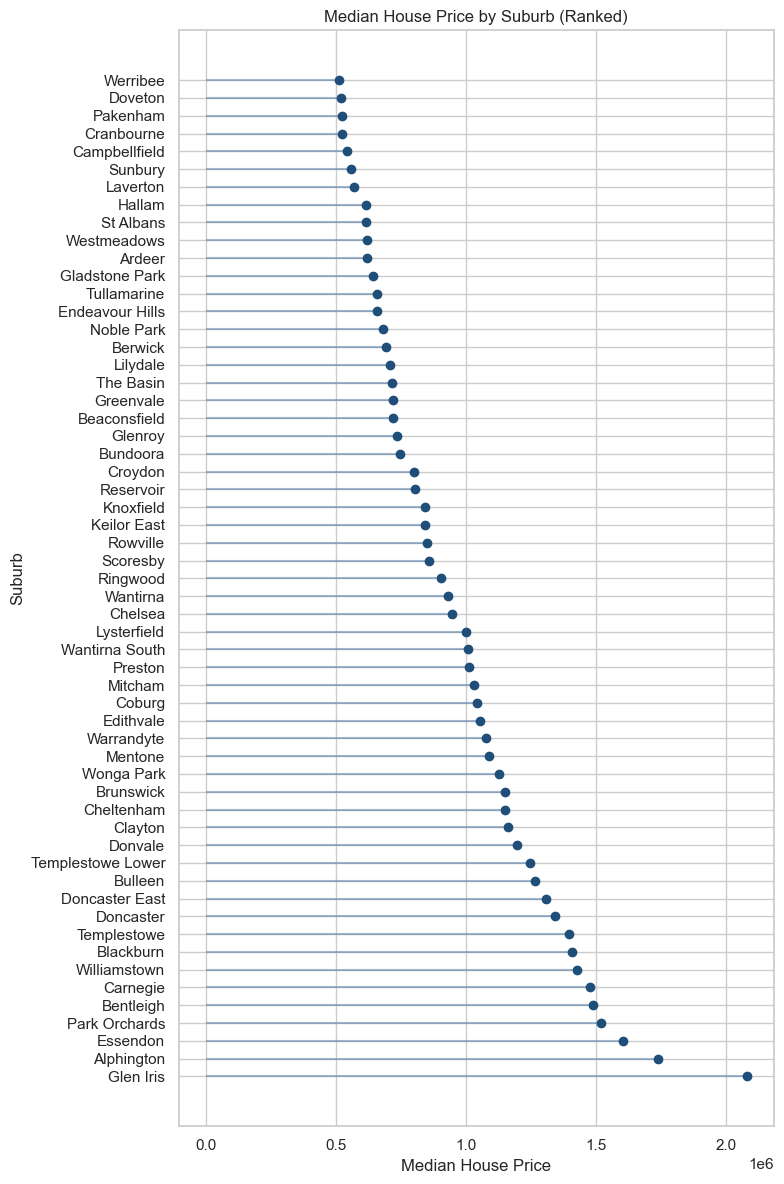

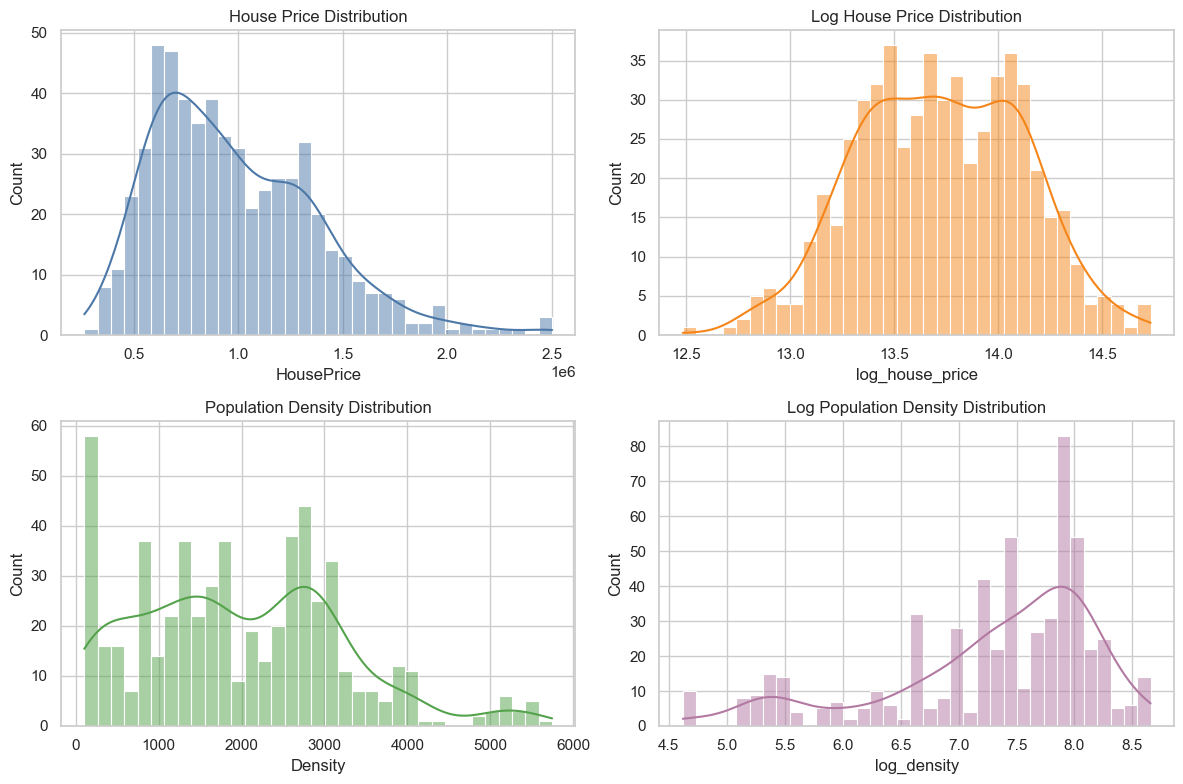

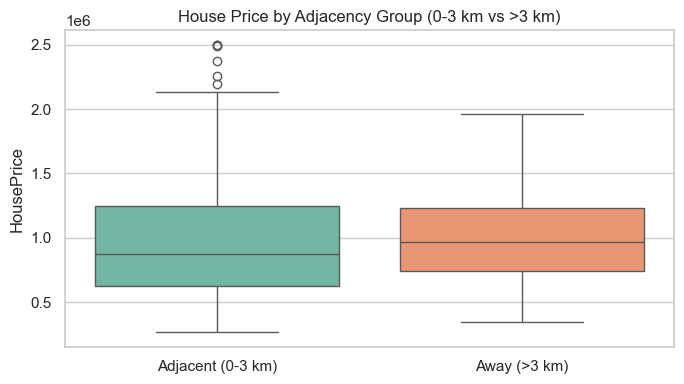

In [7]:
# Coverage and cleaning diagnostics
print("Unique suburbs in prices:", prices_long["Suburb"].nunique())
print("Unique suburbs in density:", density_long["Suburb"].nunique())
print("Unique suburbs in merged EDA:", eda["Suburb"].nunique())
print("Year span in merged EDA:", int(eda["Year"].min()), "to", int(eda["Year"].max()))
print("Missing values by column:")
print(eda[["Suburb", "Year", "HousePrice", "Density", "nearest_LXRP_km", "adjacent_group"]].isna().sum())

missing_group = eda["adjacent_group"].isna().sum()
if missing_group > 0:
    print("Suburbs missing adjacency group:", sorted(eda.loc[eda["adjacent_group"].isna(), "Suburb"].unique()))

# Ranked median house price by suburb
suburb_median = (
    eda.groupby("Suburb", as_index=False)["HousePrice"]
    .median()
    .sort_values("HousePrice", ascending=False)
)

plt.figure(figsize=(8, 12))
plt.hlines(y=suburb_median["Suburb"], xmin=0, xmax=suburb_median["HousePrice"], color="#4C78A8", alpha=0.5)
plt.plot(suburb_median["HousePrice"], suburb_median["Suburb"], "o", color="#1f4e79")
plt.title("Median House Price by Suburb (Ranked)")
plt.xlabel("Median House Price")
plt.ylabel("Suburb")
plt.tight_layout()
plt.show()

# Distribution plots
eda["log_house_price"] = np.log(eda["HousePrice"])
eda["log_density"] = np.log(eda["Density"])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(eda["HousePrice"], bins=35, kde=True, ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("House Price Distribution")

sns.histplot(eda["log_house_price"], bins=35, kde=True, ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Log House Price Distribution")

sns.histplot(eda["Density"], bins=35, kde=True, ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("Population Density Distribution")

sns.histplot(eda["log_density"], bins=35, kde=True, ax=axes[1, 1], color="#B279A2")
axes[1, 1].set_title("Log Population Density Distribution")

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(data=eda, x="adjacent_group", y="HousePrice", hue="adjacent_group", palette="Set2", legend=False)
plt.title("House Price by Adjacency Group (0-3 km vs >3 km)")
plt.xlabel("")
plt.tight_layout()
plt.show()

## Justification for each graph

The raw variables are broadly what we would expect from housing data: prices are strongly right-skewed and density is also right-skewed, with a few suburbs sitting well above the rest. The log versions compress those tails, which is useful for later modelling because it reduces leverage from extreme suburbs and makes the distributions closer to symmetric.

1. **Median House Price by Suburb (Ranked dot/lollipop chart)**

This graph gives a fast cross-suburb comparison of central price levels without being overly affected by one-off yearly spikes. For 56+ suburbs, median is a robust summary that helps identify high-price and low-price markets before any modelling.

Each point is one suburb's median house price across the sample years, sorted from highest to lowest. Large vertical spread means substantial suburb-level heterogeneity, which suggests suburb effects are likely important in later models.

2. **House Price Distribution (raw) and Log House Price Distribution**

The raw histogram checks shape, skewness, and potential extreme values. The log version checks whether a transformation produces a more symmetric distribution, which is often preferable for linear modelling and interpretation of relative changes.

In raw scale, house prices are usually right-skewed with a long upper tail. In log scale, the distribution is typically tighter and closer to bell-shaped, supporting the use of log(price) in subsequent analysis.

3. **Population Density Distribution (raw) and Log Population Density Distribution**

Density is the key explanatory variable in this reduced setup, so its spread and skew must be understood before using it in regression or correlation analysis. The log plot checks whether transformation reduces leverage from very high-density suburbs.

Raw density often shows concentration at lower-to-mid values with a right tail. Log density compresses extreme values, making differences across most suburbs easier to compare and reducing distortion from outliers.

4. **House Price by Adjacency Group (Box-and-Whisker)**

This directly links to the research question by comparing price level distributions between suburbs adjacent to the line (0-3 km) and those away (>3 km). It is a first-pass group comparison before testing growth or causal effects.

The box shows median and interquartile range, whiskers show broader spread, and points beyond whiskers indicate outliers. Differences in medians suggest baseline level differences, while differences in spread indicate heterogeneity within groups. This is descriptive, not causal, but it helps motivate next-stage modelling.

## 2) Correlation and First-Order Effects

This section looks for a first-order relationship between density and house price, and checks whether suburb-level aggregation changes the story. The goal is to see whether the raw correlation is robust or whether it is driven by composition effects, which would matter for later modelling choices.

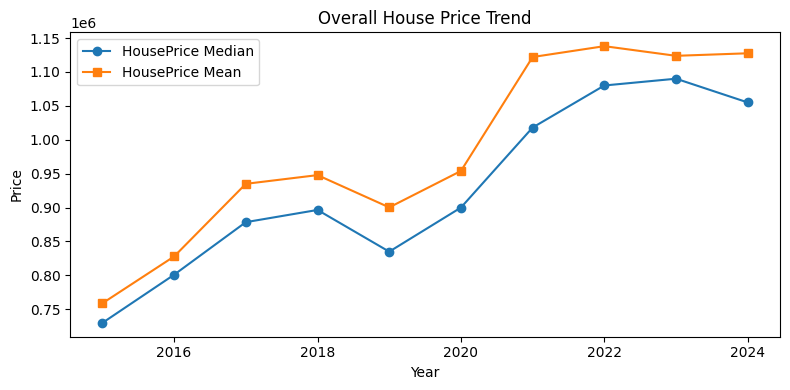

**Interpretation:** House prices rise over time, and the mean and median move together fairly closely, so the aggregate trend is not being driven by a tiny number of extreme suburbs alone. This points to a common time effect that should be controlled for later.

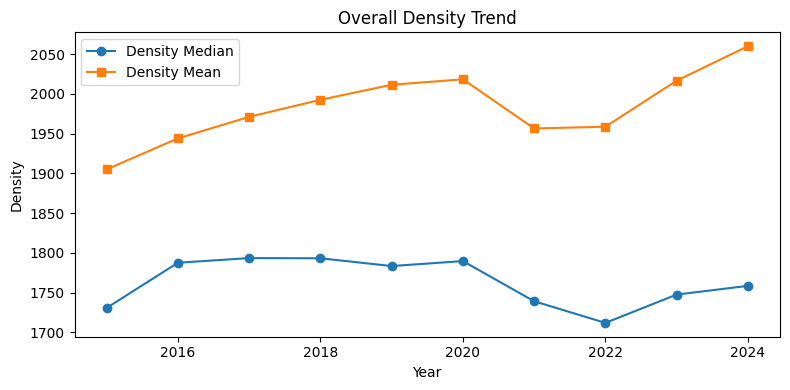

**Interpretation:** Density is much flatter over time, which is what we would expect for a built-environment variable. The modest mean/median gap suggests the density distribution is relatively stable, so it is less likely to be a pure time trend.

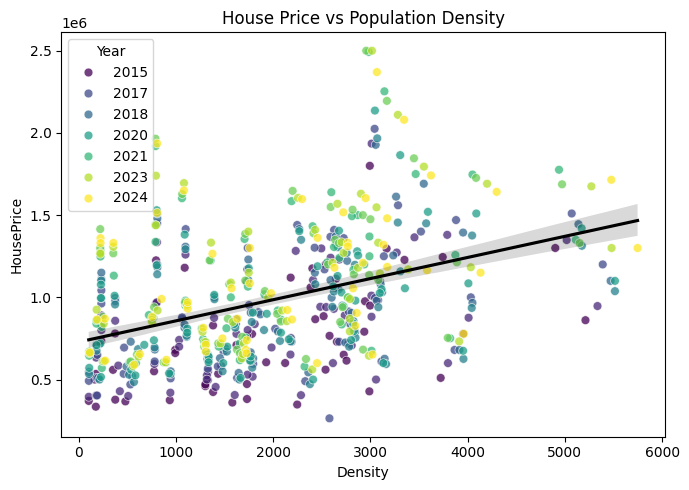

**Interpretation:** The raw price-density relationship is weak and noisy, so there is at most a small first-order effect in the pooled data. The year colouring also suggests that time and suburb structure matter, so a simple bivariate slope would be risky.

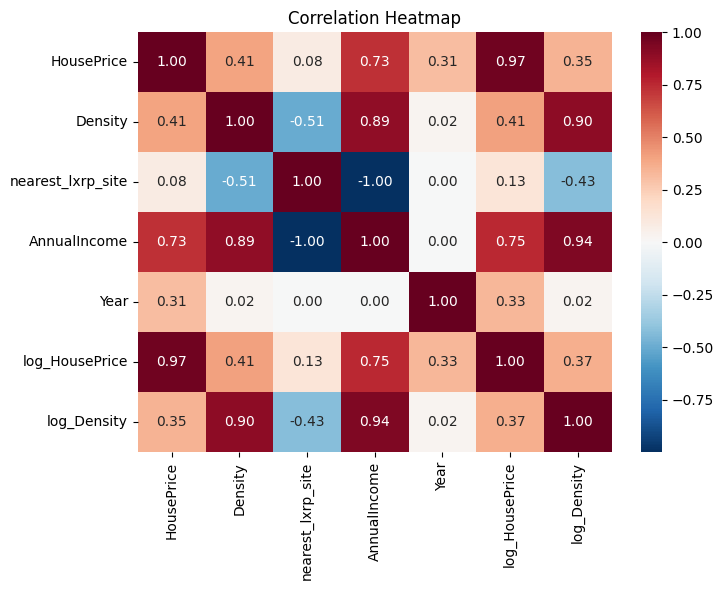

**Interpretation:** The strongest relationships are with the log transforms and with year, while the direct price-density link is weaker. That suggests using transformed variables and controlling for time and suburb structure will matter more than relying on raw correlation alone.

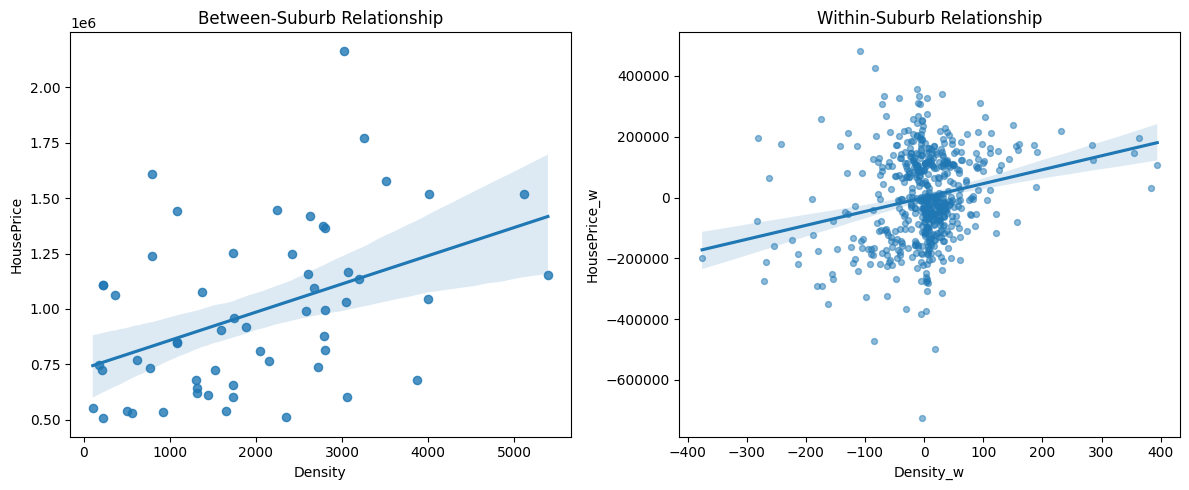

**Interpretation:** The between-suburb and within-suburb slopes are not identical, which is a warning sign for composition effects. A pooled relationship could therefore hide a different within-suburb pattern, so later modelling should separate suburb-level and time variation.

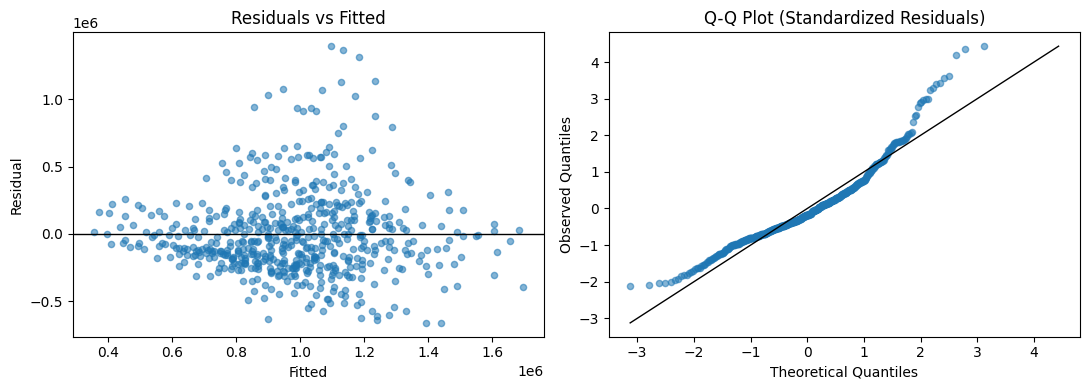

**Interpretation:** The residual plot and Q-Q plot show that a simple linear fit does not fully capture the data structure, with tail behaviour and changing spread still visible. That argues for transformed outcomes or a panel-style specification rather than a raw OLS slope.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

# -----------------------------
# 1) Load and prepare data
# -----------------------------
YEARS = list(range(2015, 2025))
YEAR_STR = [str(y) for y in YEARS]

project_root = Path.cwd()
if not (project_root / "data" / "clean").exists():
    project_root = project_root.parent

clean = project_root / "data" / "clean"

def melt_wide(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    out = df.melt(id_vars=["Suburb"], value_vars=YEAR_STR, var_name="Year", value_name=value_name)
    out["Year"] = pd.to_numeric(out["Year"], errors="coerce").astype(int)
    out[value_name] = pd.to_numeric(out[value_name], errors="coerce")
    return out

def erfinv_approx(x: float) -> float:
    # Winitzki approximation for inverse error function (for Q-Q plot)
    a = 0.147
    sign = 1 if x >= 0 else -1
    ln = np.log(1 - x * x + 1e-12)
    first = 2 / (np.pi * a) + ln / 2
    second = ln / a
    return sign * np.sqrt(np.sqrt(first * first - second) - first)

def build_lxrp_table() -> pd.DataFrame:
    suburbs = [
        ("Chelsea", 4), ("Laverton", 3), ("Ringwood", 2), ("Mentone", 2), ("Preston", 1),
        ("Blackburn", 2), ("Beaconsfield", 2), ("Essendon", 1), ("Glen Iris", 1),
        ("Cranbourne", 3), ("Campbellfield", 3), ("Pakenham", 3), ("Lilydale", 2),
        ("Bentleigh", 1), ("Clayton", 2), ("Noble Park", 2), ("Cheltenham", 2),
        ("Werribee", 3), ("Berwick", 3), ("Croydon", 0), ("Edithvale", 2),
        ("Williamstown", 1), ("Ardeer", 1), ("St Albans", 1), ("Sunbury", 2),
        ("Glenroy", 0), ("Alphington", 1), ("Carnegie", 1), ("Hallam", 3),
        ("Mitcham", 2), ("Reservoir", 0), ("Coburg", 0), ("Brunswick", 0), ("Bundoora", 4),
        ("Doncaster", 10), ("Doncaster East", 12), ("Donvale", 9), ("Templestowe", 8),
        ("Templestowe Lower", 6), ("Warrandyte", 12), ("Wonga Park", 15), ("Park Orchards", 9),
        ("Bulleen", 10), ("Rowville", 10), ("Lysterfield", 11), ("Scoresby", 9),
        ("Knoxfield", 9), ("Wantirna", 6), ("Wantirna South", 7), ("The Basin", 7),
        ("Endeavour Hills", 6), ("Doveton", 4), ("Greenvale", 7), ("Gladstone Park", 6),
        ("Westmeadows", 3), ("Tullamarine", 6), ("Keilor East", 4),
    ]
    return pd.DataFrame(suburbs, columns=["Suburb", "nearest_lxrp_site"]).drop_duplicates("Suburb")

density_wide = pd.read_csv(clean / "requested_suburbs_density_2015_2024.csv").drop(columns=["No."], errors="ignore")
price_wide = pd.read_csv(clean / "closest_lxrp_site_house_prices_2015_2024.csv")
income = pd.read_csv(clean / "annual_household_income_table.csv")
lxrp = build_lxrp_table()

density_long = melt_wide(density_wide, "Density")
price_long = melt_wide(price_wide, "HousePrice")

panel = (
    price_long
    .merge(density_long, on=["Suburb", "Year"], how="inner")
    .merge(lxrp, on="Suburb", how="left")
    .merge(income.rename(columns={"Annual total household income ($/year)": "AnnualIncome"}), on="Suburb", how="left")
)

panel["log_HousePrice"] = np.log(panel["HousePrice"])
panel["log_Density"] = np.log(panel["Density"].clip(lower=1e-9))

# -----------------------------
# 2) Graph 10: Overall house price trend
# -----------------------------
yearly = panel.groupby("Year", as_index=False).agg(
    HousePriceMedian=("HousePrice", "median"),
    HousePriceMean=("HousePrice", "mean"),
    DensityMedian=("Density", "median"),
    DensityMean=("Density", "mean"),
)

plt.figure(figsize=(8, 4))
plt.plot(yearly["Year"], yearly["HousePriceMedian"], marker="o", label="HousePrice Median")
plt.plot(yearly["Year"], yearly["HousePriceMean"], marker="s", label="HousePrice Mean")
plt.title("Overall House Price Trend")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown("**Interpretation:** House prices rise over time, and the mean and median move together fairly closely, so the aggregate trend is not being driven by a tiny number of extreme suburbs alone. This points to a common time effect that should be controlled for later."))

# -----------------------------
# 3) Graph 11: Overall density trend
# -----------------------------
plt.figure(figsize=(8, 4))
plt.plot(yearly["Year"], yearly["DensityMedian"], marker="o", label="Density Median")
plt.plot(yearly["Year"], yearly["DensityMean"], marker="s", label="Density Mean")
plt.title("Overall Density Trend")
plt.xlabel("Year")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown("**Interpretation:** Density is much flatter over time, which is what we would expect for a built-environment variable. The modest mean/median gap suggests the density distribution is relatively stable, so it is less likely to be a pure time trend."))

# -----------------------------
# 4) Graph 12: Scatter price vs density
# -----------------------------
plt.figure(figsize=(7, 5))
sns.scatterplot(data=panel, x="Density", y="HousePrice", hue="Year", palette="viridis", s=40, alpha=0.75)
sns.regplot(data=panel, x="Density", y="HousePrice", scatter=False, color="black")
plt.title("House Price vs Population Density")
plt.tight_layout()
plt.show()

display(Markdown("**Interpretation:** The raw price-density relationship is weak and noisy, so there is at most a small first-order effect in the pooled data. The year colouring also suggests that time and suburb structure matter, so a simple bivariate slope would be risky."))

# -----------------------------
# 5) Graph 14: Correlation heatmap
# -----------------------------
corr_cols = ["HousePrice", "Density", "nearest_lxrp_site", "AnnualIncome", "Year", "log_HousePrice", "log_Density"]
corr = panel[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

display(Markdown("**Interpretation:** The strongest relationships are with the log transforms and with year, while the direct price-density link is weaker. That suggests using transformed variables and controlling for time and suburb structure will matter more than relying on raw correlation alone."))

# -----------------------------
# 6) Graph 15: Simpson's check (between vs within)
# -----------------------------
between = panel.groupby("Suburb", as_index=False)[["HousePrice", "Density"]].mean()

within = panel.copy()
within["HousePrice_w"] = within["HousePrice"] - within.groupby("Suburb")["HousePrice"].transform("mean")
within["Density_w"] = within["Density"] - within.groupby("Suburb")["Density"].transform("mean")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=between, x="Density", y="HousePrice", ax=axs[0], scatter_kws={"s": 35})
axs[0].set_title("Between-Suburb Relationship")

sns.regplot(data=within, x="Density_w", y="HousePrice_w", ax=axs[1], scatter_kws={"s": 18, "alpha": 0.5})
axs[1].set_title("Within-Suburb Relationship")

plt.tight_layout()
plt.show()

display(Markdown("**Interpretation:** The between-suburb and within-suburb slopes are not identical, which is a warning sign for composition effects. A pooled relationship could therefore hide a different within-suburb pattern, so later modelling should separate suburb-level and time variation."))

# -----------------------------
# 7) Graph 17: OLS diagnostics
# -----------------------------
ols = panel[["HousePrice", "Density", "nearest_lxrp_site", "Year"]].dropna().copy()

X = np.column_stack([
    np.ones(len(ols)),
    ols["Density"].to_numpy(),
    ols["nearest_lxrp_site"].to_numpy(),
    ols["Year"].to_numpy(),
])
y = ols["HousePrice"].to_numpy()

beta, *_ = np.linalg.lstsq(X, y, rcond=None)
fitted = X @ beta
resid = y - fitted

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

# Residuals vs fitted
axs[0].scatter(fitted, resid, alpha=0.55, s=20)
axs[0].axhline(0, color="black", lw=1)
axs[0].set_title("Residuals vs Fitted")
axs[0].set_xlabel("Fitted")
axs[0].set_ylabel("Residual")

# Q-Q style plot
n = len(resid)
obs = np.sort((resid - resid.mean()) / (resid.std(ddof=1) + 1e-12))
probs = (np.arange(1, n + 1) - 0.5) / n
theor = np.sqrt(2) * np.vectorize(erfinv_approx)(2 * probs - 1)

mn, mx = min(theor.min(), obs.min()), max(theor.max(), obs.max())
axs[1].scatter(theor, obs, alpha=0.55, s=20)
axs[1].plot([mn, mx], [mn, mx], color="black", lw=1)
axs[1].set_title("Q-Q Plot (Standardized Residuals)")
axs[1].set_xlabel("Theoretical Quantiles")
axs[1].set_ylabel("Observed Quantiles")

plt.tight_layout()
plt.show()

display(Markdown("**Interpretation:** The residual plot and Q-Q plot show that a simple linear fit does not fully capture the data structure, with tail behaviour and changing spread still visible. That argues for transformed outcomes or a panel-style specification rather than a raw OLS slope."))